# Task 2: Immediate Exploitation Strategy (Pure Greedy)
**Group Number:** G = 225  
**Assignment:** DRL Semester 2 – Phase #1 (MAB)  
**Strategy:** Test each medicine 10 times (round-robin), then permanently lock in the best-performing arm for all remaining patients.

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 0 – Library Imports
# ─────────────────────────────────────────────────────────────────

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 – Restore Group Configuration & Reproducibility Seeds
#
# Loads the group configuration saved by Task 1 (group_config.json)
# and re-seeds both random engines to the same G=225 value so that
# simulate_treatment() produces reproducible Bernoulli draws.
# ─────────────────────────────────────────────────────────────────

# ── Locate the data directory relative to this notebook ──────────
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR     = os.path.join(NOTEBOOK_DIR, "data")
CONFIG_PATH  = os.path.join(DATA_DIR, "group_config.json")
PARQUET_PATH = os.path.join(DATA_DIR, "df_base.parquet")

# ── Load configuration ────────────────────────────────────────────
with open(CONFIG_PATH, "r") as f:
    cfg = json.load(f)

G      = cfg["G"]
K      = cfg["K"]
TRUE_P = cfg["TRUE_P"]

# ── Re-seed for reproducibility (same seed as Task 1) ─────────────
np.random.seed(G)

print("Configuration restored from group_config.json")
print(f"  G (Group Number)              : {G}")
print(f"  K (Number of Medicines/Arms)  : {K}")
print(f"  TRUE_P (Hidden Probabilities) : {TRUE_P}")

Configuration restored from group_config.json
  G (Group Number)              : 225
  K (Number of Medicines/Arms)  : 5
  TRUE_P (Hidden Probabilities) : [0.61, 0.68, 0.75, 0.4, 0.47]


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 – Load df_base from Parquet
#
# Reads the clean base DataFrame persisted by Task 1.
# patient_id is restored as the index to match the original schema.
# ─────────────────────────────────────────────────────────────────

df_base = pd.read_parquet(PARQUET_PATH)
df_base.set_index("patient_id", inplace=True)

print(f"df_base loaded: {df_base.shape[0]} rows × {df_base.shape[1]} columns")
print(f"Columns        : {list(df_base.columns)}")
print()
print("First 5 rows (dynamic columns should be NaN):")
print(df_base.head())

df_base loaded: 1000 rows × 4 columns
Columns        : ['severity_score', 'assigned_medicine', 'clinical_outcome', 'utility_score']

First 5 rows (dynamic columns should be NaN):
            severity_score  assigned_medicine  clinical_outcome  utility_score
patient_id                                                                    
0                        1                NaN               NaN            NaN
1                        2                NaN               NaN            NaN
2                        3                NaN               NaN            NaN
3                        4                NaN               NaN            NaN
4                        5                NaN               NaN            NaN


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 – Environmental Feedback Engine: simulate_treatment()
#
# Identical definition to Task 1. Redefined here so this notebook
# is fully self-contained when run independently.
# ─────────────────────────────────────────────────────────────────

def simulate_treatment(medicine_idx: int, severity_score: int) -> tuple:
    """
    Simulate administering a medicine to a patient.

    Returns
    -------
    (clinical_outcome, utility_score) : tuple(int, float)
      clinical_outcome – 1 if recovered, 0 otherwise (Bernoulli trial)
      utility_score    – severity-penalised reward: outcome × (1 − sev/10)
    """
    success_prob     = TRUE_P[medicine_idx]
    clinical_outcome = int(np.random.binomial(1, success_prob))
    utility_score    = clinical_outcome * (1 - severity_score / 10)
    return (clinical_outcome, utility_score)

print("simulate_treatment() defined.")

simulate_treatment() defined.


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 – Task 2: Immediate Exploitation Strategy (Pure Greedy)
#
# Algorithm outline
# -----------------
# Phase 1 (patients 0–49):  Round-robin forced exploration.
#   Each of the K=5 medicines is tested exactly 10 times in order.
#   assigned_medicine = patient_id % K
#
# Decision gate (patient 50):  Compute empirical success rate per
#   medicine (success_counts / pull_counts).  Lock in the medicine
#   with the highest rate via np.argmax.
#
# Phase 2 (patients 50–999):  Pure exploitation – always prescribe
#   the single best medicine selected above.
#
# Statistics updated using clinical_outcome only (binary 0/1).
# Cumulative reward tracked using utility_score.
# ─────────────────────────────────────────────────────────────────

# ── Working copy of the base DataFrame ───────────────────────────
df_greedy = df_base.copy(deep=True)

# ── Bandit statistics accumulators ───────────────────────────────
success_counts = np.zeros(K, dtype=float)   # total recoveries per medicine
pull_counts    = np.zeros(K, dtype=float)   # total pulls per medicine

# ── Reward tracking ───────────────────────────────────────────────
cumulative_reward      = 0.0
greedy_utility_history = []   # running cumulative reward at every step

# ── Greedy lock variable (set at patient 50) ──────────────────────
best_medicine = None

# ── Main simulation loop ──────────────────────────────────────────
for patient_id in range(1000):

    severity = int(df_greedy.at[patient_id, "severity_score"])

    # ── Decision Gate: lock in best medicine exactly at patient 50 ──
    if patient_id == 50:
        # Empirical success rate = recoveries / pulls for each medicine
        empirical_rates = success_counts / pull_counts  # shape (K,)
        best_medicine   = int(np.argmax(empirical_rates))
        # (No prescription for patient 50 yet – that happens below)

    # ── Select medicine ───────────────────────────────────────────
    if patient_id < 50:
        # Phase 1: forced round-robin
        chosen_medicine = patient_id % K
    else:
        # Phase 2: pure exploitation – always use best_medicine
        chosen_medicine = best_medicine

    # ── Simulate treatment and collect feedback ───────────────────
    clinical_outcome, utility_score = simulate_treatment(chosen_medicine, severity)

    # ── Update bandit statistics (use binary clinical_outcome only) ─
    success_counts[chosen_medicine] += clinical_outcome
    pull_counts[chosen_medicine]    += 1

    # ── Populate df_greedy row-by-row ─────────────────────────────
    df_greedy.at[patient_id, "assigned_medicine"] = chosen_medicine
    df_greedy.at[patient_id, "clinical_outcome"]  = clinical_outcome
    df_greedy.at[patient_id, "utility_score"]     = utility_score

    # ── Accumulate reward (use utility_score, NOT for stat update) ─
    cumulative_reward += utility_score
    greedy_utility_history.append(cumulative_reward)

print("Greedy simulation complete.")
print(f"Total iterations : {len(greedy_utility_history)}")

Greedy simulation complete.
Total iterations : 1000


In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 – Verification & Output
#
# 1. Which medicine was permanently selected and its Phase 1 rate.
# 2. Final cumulative reward.
# 3. Transition slice df_greedy.iloc[45:55] to verify column fill.
# ─────────────────────────────────────────────────────────────────

# Recompute Phase 1 empirical rates for reporting
empirical_rates_final = success_counts / pull_counts

print("=" * 60)
print("TASK 2 – PURE GREEDY RESULTS")
print("=" * 60)

print()
print("Phase 1 Empirical Success Rates (after 50 patients, 10 pulls each):")
for idx in range(K):
    marker = "  ← SELECTED" if idx == best_medicine else ""
    print(f"  Medicine {idx}: {empirical_rates_final[idx]:.4f}  "
          f"(true P = {TRUE_P[idx]:.2f}){marker}")

print()
print(f"Permanently selected medicine : {best_medicine}")
print(f"Phase 1 sample success rate   : {empirical_rates_final[best_medicine]:.4f}")
print(f"True success probability      : {TRUE_P[best_medicine]:.4f}")

print()
print(f"Final cumulative_reward (1000 patients) : {cumulative_reward:.4f}")

print()
print("-" * 60)
print("Transition slice – df_greedy.iloc[45:55]")
print("(rows 45–49 = Phase 1 round-robin | rows 50–54 = Phase 2 lock-in)")
print("-" * 60)
print(df_greedy.reset_index().iloc[45:55].to_string(index=False))
print("=" * 60)

TASK 2 – PURE GREEDY RESULTS

Phase 1 Empirical Success Rates (after 50 patients, 10 pulls each):
  Medicine 0: 0.6000  (true P = 0.61)
  Medicine 1: 0.4000  (true P = 0.68)
  Medicine 2: 0.7417  (true P = 0.75)  ← SELECTED
  Medicine 3: 0.6000  (true P = 0.40)
  Medicine 4: 0.6000  (true P = 0.47)

Permanently selected medicine : 2
Phase 1 sample success rate   : 0.7417
True success probability      : 0.7500

Final cumulative_reward (1000 patients) : 513.1000

------------------------------------------------------------
Transition slice – df_greedy.iloc[45:55]
(rows 45–49 = Phase 1 round-robin | rows 50–54 = Phase 2 lock-in)
------------------------------------------------------------
 patient_id  severity_score  assigned_medicine  clinical_outcome  utility_score
         45               1                0.0               1.0            0.9
         46               2                1.0               1.0            0.8
         47               3                2.0               1.0 

In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 – Persist Outputs for Task 5 (Comparative Plots)
#
# Saves df_greedy and greedy_utility_history so the Task 5 notebook
# can load them alongside outputs from other algorithms and generate
# the comparative reward curve without re-running simulations.
# ─────────────────────────────────────────────────────────────────

GREEDY_PARQUET_PATH  = os.path.join(DATA_DIR, "df_greedy.parquet")
GREEDY_HISTORY_PATH  = os.path.join(DATA_DIR, "greedy_utility_history.npy")

# Save df_greedy (reset index so patient_id is a regular column)
df_greedy.reset_index().to_parquet(GREEDY_PARQUET_PATH, index=False)

# Save utility history as a NumPy array
np.save(GREEDY_HISTORY_PATH, np.array(greedy_utility_history))

print(f"df_greedy saved             → {GREEDY_PARQUET_PATH}")
print(f"greedy_utility_history saved → {GREEDY_HISTORY_PATH}")
print(f"df_greedy shape             : {df_greedy.shape}")
print(f"History length              : {len(greedy_utility_history)}")

df_greedy saved             → c:\Users\rohit\OneDrive\Desktop\BITSWILP\2ndSem\DRL\gitcode\SEM2_DRL_ASSIGNMENT_PART1\Phase#1\data\df_greedy.parquet
greedy_utility_history saved → c:\Users\rohit\OneDrive\Desktop\BITSWILP\2ndSem\DRL\gitcode\SEM2_DRL_ASSIGNMENT_PART1\Phase#1\data\greedy_utility_history.npy
df_greedy shape             : (1000, 4)
History length              : 1000


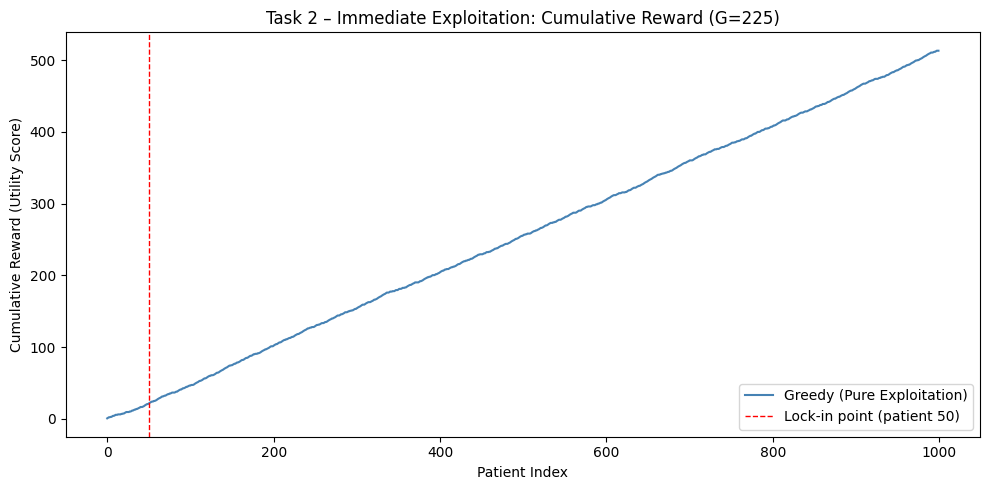

In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 7 – Quick Reward Curve (Task 2 Preview)
#
# Plots the cumulative reward trajectory for the pure greedy
# strategy.  The visible 'kink' at patient 50 marks the transition
# from round-robin exploration to full exploitation.
# ─────────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 5))
plt.plot(greedy_utility_history, color="steelblue", linewidth=1.5,
         label="Greedy (Pure Exploitation)")
plt.axvline(x=50, color="red", linestyle="--", linewidth=1,
            label="Lock-in point (patient 50)")
plt.xlabel("Patient Index")
plt.ylabel("Cumulative Reward (Utility Score)")
plt.title("Task 2 – Immediate Exploitation: Cumulative Reward (G=225)")
plt.legend()
plt.tight_layout()
plt.show()